# Assignment 5 – Task 3: Gesture-based Media Controls

This notebook trains a CNN to recognize the hand gestures **dislike**, **like**, and **stop**, and then uses the trained model to control media playback in real time via the webcam, sending media keys with the `pynput` library.

## Approach 
- Gesture → action mapping was chosen so it's intuitive:
    - **like** → volume up (*more* = louder)
    - **dislike** → volume down (the natural opposite of like)
    - **stop** → play / pause (a clear "go ahead" gesture toggles playback)



In [27]:
import cv2
import json
import os
import time
import numpy as np
from matplotlib import pyplot as plt

from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomContrast
from keras.metrics import categorical_crossentropy
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.utils import to_categorical

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from pynput.keyboard import Controller, Key

# the three gestures we train on - "no gesture" is handled via a confidence
# threshold at inference time instead of a dedicated trained class (see below)
CONDITIONS = ['dislike', 'like', 'stop']

IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)
COLOR_CHANNELS = 3

PATH = r'C:\Users\Thomas Lucke\Documents\assignment-05-cnn-Tholuc\01-hyperparameters\gesture_dataset_sample'

## Load annotations

Same helper as the course notebook, just looped over our three `CONDITIONS`.

In [28]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

## Pre-processing and data loading

Identical to the course notebook: 

In [29]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.resize(img, SIZE)

In [30]:
images = []      # preprocessed image crops
labels = []       # integer label per image
label_names = []  # maps label index -> gesture name

for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'{PATH}/{condition}')):
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')

        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue

        for i, bbox in enumerate(annotation['bboxes']):
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h

            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)

            label = annotation['labels'][i]
            if label not in label_names:
                label_names.append(label)

            images.append(preprocessed)
            labels.append(label_names.index(label))

print(f'loaded {len(images)} images across classes: {label_names}')

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

loaded 971 images across classes: ['no_gesture', 'dislike', 'like', 'stop']


### Sanity check: one example per class

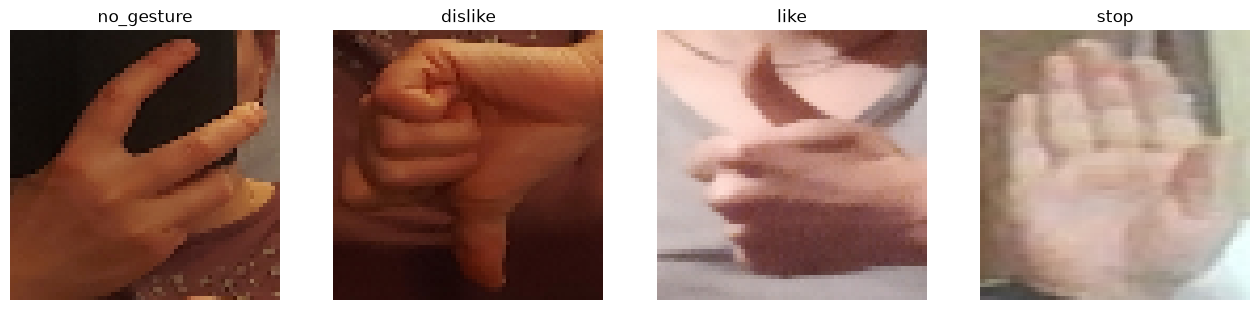

In [31]:
fig, axes = plt.subplots(1, len(label_names), figsize=(4 * len(label_names), 4))

for ax, name in zip(axes, label_names):
    idx = labels.index(label_names.index(name))
    img = images[idx]
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if COLOR_CHANNELS == 3 else img,
               cmap=None if COLOR_CHANNELS == 3 else 'gray')
    ax.set_title(name)
    ax.axis('off')

## Train / test split

Same 80/20 split as the course notebook. We additionally `stratify` by label so every gesture is represented proportionally in both sets — useful if the three classes aren't perfectly balanced in size.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

print(len(X_train), 'train /', len(X_test), 'test images')

776 train / 195 test images


In [33]:
X_train = np.array(X_train).astype('float32') / 255.
X_test = np.array(X_test).astype('float32') / 255.

train_label = to_categorical(y_train)
test_label = to_categorical(y_test)

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(776, 64, 64, 3) (195, 64, 64, 3) (776, 4) (195, 4)


## Model

The exact same CNN architecture as the notebook we got in class

In [34]:
batch_size = 8
epochs = 50
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'
layer_count = 2
num_neurons = 64

model = Sequential()

# data augmentation
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))

# convolution + pooling blocks
model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

model.add(Dropout(0.2))
model.add(Flatten())

# fully connected layers
for _ in range(layer_count - 1):
    model.add(Dense(num_neurons, activation=activation))
model.add(Dense(num_neurons, activation=activation))

# classifier
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=categorical_crossentropy, optimizer='adam', metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

c:\Users\Thomas Lucke\Documents\assignment-05-cnn-Tholuc\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.3067 - loss: 1.3868 - val_accuracy: 0.3590 - val_loss: 1.3928 - learning_rate: 0.0010
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4008 - loss: 1.3024 - val_accuracy: 0.4615 - val_loss: 1.2069 - learning_rate: 0.0010
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6289 - loss: 0.9085 - val_accuracy: 0.7128 - val_loss: 0.7252 - learning_rate: 0.0010
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7242 - loss: 0.6996 - val_accuracy: 0.8462 - val_loss: 0.5660 - learning_rate: 0.0010
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8144 - loss: 0.4950 - val_accuracy: 0.8462 - val_loss: 0.4436 - learning_rate: 0.0010
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8544 - loss: 0.4007 - val_accuracy: 0.8462 - val_loss: 0.3553 - learning_rate: 0.0010
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8557 - loss: 0.3625 - val_acc

In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (8, 64, 64, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (8, 64, 64, 3)         │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (8, 64, 64, 64)        │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (8, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (8, 16, 16, 32)        │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (8, 6, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (8, 6, 6, 32)          │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (8, 288)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (8, 64)                │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (8, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (8, 4)                 │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,038 (1.13 MB)

 Trainable params: 99,012 (386.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 198,026 (773.54 KB)

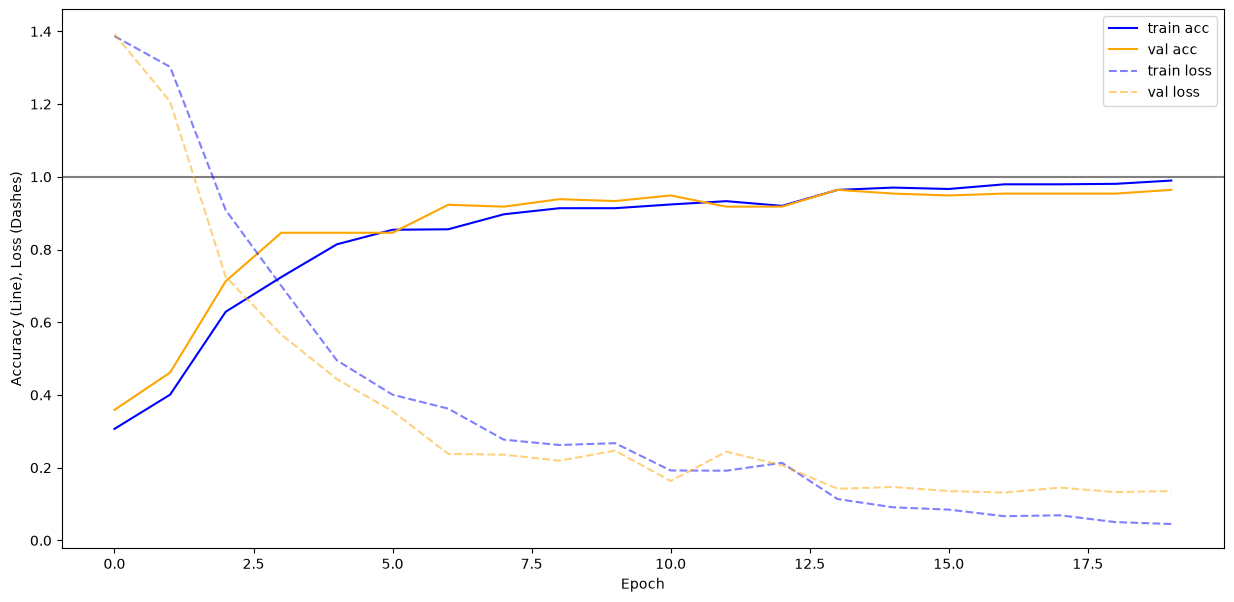

In [37]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')
ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue', label='train acc')
plt.plot(val_accuracy, color='orange', label='val acc')
plt.plot(loss, '--', color='blue', alpha=0.5, label='train loss')
plt.plot(val_loss, '--', color='orange', alpha=0.5, label='val loss')
plt.legend()

## Confusion matrix

Checking that the model reliably tells the three gestures apart before wiring it up to actual media controls.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


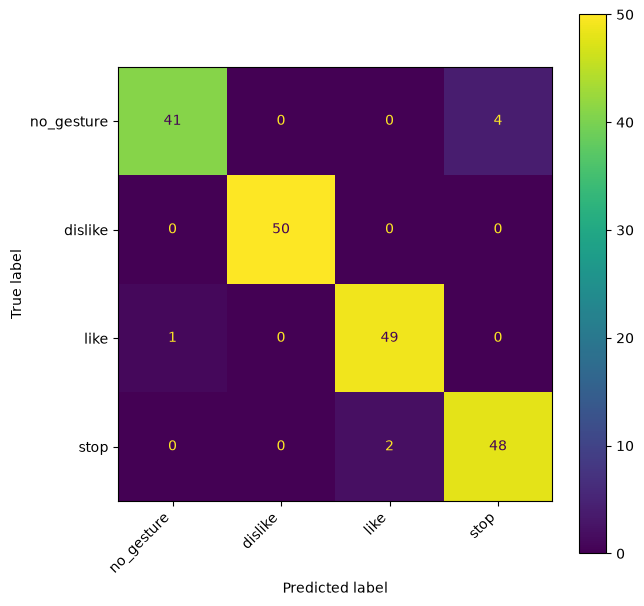

In [38]:
y_predictions = model.predict(X_test)
y_predictions = np.argmax(y_predictions, axis=1)

conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(7, 7))
ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())
plt.xticks(rotation=45, ha='right')
pass

In [39]:
model.save('gesture_media_control.keras')

# and this is how you load it again later:
# from keras.models import load_model
# model = load_model('gesture_media_control.keras')

## Real-time gesture → media control

| gesture | meaning | media key sent | control feature covered |
|---|---|---|---|
| `like` | thumbs up | `Key.media_volume_up` | increase volume |
| `dislike` | thumbs down | `Key.media_volume_down` | decrease volume |
| `stop` | stop sign | `Key.media_play_pause` | start track / pause track |
| low confidence (no clear gesture) | idle | *(nothing sent)* | — |

Adjust `ROI` so u can comfortably put ur hand in the box and mostly only ur hand (you can also use a white wall background or the marker cardboard from the assignment to make the hand easier to find).

In [44]:
keyboard = Controller()

# gesture -> (key to send, human-readable action name)
GESTURE_ACTIONS = {
    'like':    (Key.media_volume_up,   'volume up'),
    'dislike': (Key.media_volume_down, 'volume down'),
    'stop':      (Key.media_play_pause,  'play / pause'),
}

CONFIDENCE_THRESHOLD = 0.70   # below this, treat the frame as "no_gesture"
STABLE_FRAMES = 2             # gesture must repeat this many frames in a row before it fires
COOLDOWN_SECONDS = 0.5        # minimum time between two triggers of the *same* gesture

ROI = (150, 400, 300, 450)    # y1, y2, x1, x2 - adjust to your webcam / desk setup


def predict_gesture(frame):
    """Crop the region of interest, run it through the model, return (label, confidence)."""
    y1, y2, x1, x2 = ROI
    crop = frame[y1:y2, x1:x2]
    img = preprocess_image(crop).astype('float32') / 255.
    img = img.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

    probs = model.predict(img, verbose=0)[0]
    idx = np.argmax(probs)
    confidence = float(probs[idx])
    label = label_names[idx]

    if confidence < CONFIDENCE_THRESHOLD:
        label = 'no_gesture'

    return label, confidence

In [45]:
def run_media_controller():
    cap = cv2.VideoCapture(0)
    # uncomment on macOS if the camera image starts out black:
    # time.sleep(1)

    last_label = 'no_gesture'
    stable_count = 0
    last_trigger_time = {gesture: 0.0 for gesture in GESTURE_ACTIONS}

    print('Show a gesture inside the green box. Press "q" in the video window to quit.')

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            label, confidence = predict_gesture(frame)

            # require a few consecutive identical predictions before acting - filters out
            # flicker without adding a large fixed delay, so latency stays low
            if label == last_label:
                stable_count += 1
            else:
                stable_count = 0
                last_label = label

            if stable_count == STABLE_FRAMES and label in GESTURE_ACTIONS:
                now = time.time()
                if now - last_trigger_time[label] > COOLDOWN_SECONDS:
                    key, action_name = GESTURE_ACTIONS[label]
                    keyboard.press(key)
                    keyboard.release(key)
                    last_trigger_time[label] = now
                    print(f'{label} ({confidence:.2f}) -> {action_name}')

            # visual feedback so you can see what the model sees, live
            y1, y2, x1, x2 = ROI
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f'{label} {confidence:.2f}', (x1, max(y1 - 10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            cv2.imshow('Gesture Media Control', frame)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    finally:
        cap.release()
        cv2.destroyAllWindows()

In [47]:
run_media_controller()

Show a gesture inside the green box. Press "q" in the video window to quit.
stop (0.91) -> play / pause
stop (0.86) -> play / pause
like (0.96) -> volume up
like (0.90) -> volume up
like (0.90) -> volume up
like (0.96) -> volume up
dislike (0.83) -> volume down
